In [1]:
from itertools import cycle
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import os

import torch
from torch.utils.data import DataLoader
from diffusers import AutoencoderKL, AutoencoderKLFlux2
from transformers import get_cosine_schedule_with_warmup

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import show_batch_grid, get_number_of_parameters, prepare_noise
from pokemon_dataset import PokemonDataset
from models.LightningDiT import LightningDiT
from models.feature_encoder import MultiScaleFeatureEncoder
from drifting import (
    drifting_loss_multifeatures
)

In [3]:
DEVICE = "cuda:0"
IMG_SIZE = 128

In [4]:
# dataset_path = "/home/msst/repo/drifting/data/HumanFacesDataset/gen/"
# dataset_type = "FACES"

# # dataset_path = "/home/msst/repo/drifting/data/pokemon/images"
# # dataset_type = "POKEMON"

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


In [5]:
# dataloader = DataLoader(pokemon_dataset, batch_size=64, shuffle=True, num_workers=8)

# batch = next(iter(dataloader))
# show_batch_grid(batch, n=2, figsize=(7, 7), denormalize=True)

In [6]:
transformer = LightningDiT(
    input_size=IMG_SIZE,
    patch_size=16,
    in_channels=3,
    hidden_size=1024, #512,
    depth=16,
    num_heads=16,
    use_qknorm=True,
    use_swiglu=True,
    use_rope=True,
    use_rmsnorm=True,
    use_checkpointing=False,
).to(torch.bfloat16).to(DEVICE)


print("ViT:")
get_number_of_parameters(transformer)

opt = torch.optim.AdamW(
    transformer.parameters(), 
    lr=2e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.02,
    # lr=1e-5, 
    # betas=(0.9, 0.99),
    # weight_decay=0.01
)

ViT:
Params: 203M


In [7]:
feature_encoder = MultiScaleFeatureEncoder(
    model_name='resnet50',
    freeze=True
).to(torch.bfloat16).to(DEVICE).eval()

print("Feature encoder:")
get_number_of_parameters(feature_encoder)

# feature_encoder = torch.compile(feature_encoder)

Feature encoder:
Params: 23.5M


In [8]:
def train_drifting_with_vae(
        transformer,
        opt,
        T_list=[0.02, 0.05, 0.2],
        batch_size=128,
        gradient_accumulation=1,
        training_steps=10000,
        plot_every=250,
        seed=None,
        save_step=5000,
        loss_scaling=1.0,
        save_path="checkpoints/",
    ):
    """Train drifting model. Returns model and loss history."""
    if seed is not None:
        torch.manual_seed(seed)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer=opt,
        num_warmup_steps=min(64, training_steps // gradient_accumulation),
        num_training_steps=training_steps // gradient_accumulation,
    )

    dataloader = cycle(DataLoader(
        pokemon_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        drop_last=True
    ))

    loss_history = []
    plot_loss_acc = []
    ema = None
    pbar = tqdm(range(1, training_steps + 1))
    
    for step in pbar:
        pos = next(dataloader).to(DEVICE)

        with torch.no_grad():
            pos_features = feature_encoder(pos)

        noise = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=pos.dtype)        
        gen = transformer(noise)
        gen_features = feature_encoder(gen)

        loss = drifting_loss_multifeatures(
            x_list=gen_features,
            y_pos_list=pos_features,
            T_list=T_list,
        )
        loss = loss * loss_scaling

        loss.backward()
        if step % gradient_accumulation == 0:
            opt.step()
            scheduler.step()
            opt.zero_grad()


        plot_loss_acc.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                noise = torch.randn(18, 3, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=pos.dtype)
                gen = transformer(noise)
    
                clear_output(wait=True)
                show_batch_grid(gen, n=6, figsize=(9, 9), denormalize=True)
    
                loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
                plot_loss_acc = []
                # plt.plot(loss_history)
                plt.semilogy(loss_history)
                plt.show()
            

        if (step+1) % save_step == 0:
            os.makedirs(save_path, exist_ok=True)
            torch.save(transformer.state_dict(), f"{save_path}/transformer_step{step+1}.pth")


    return loss_history

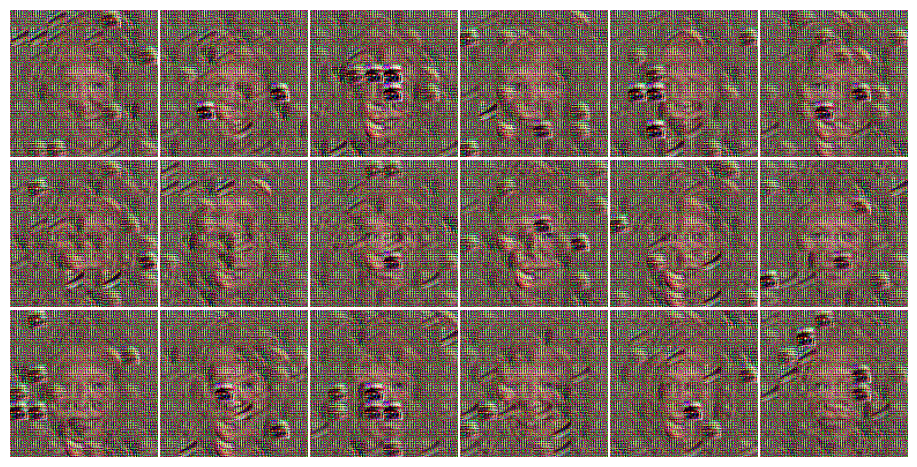

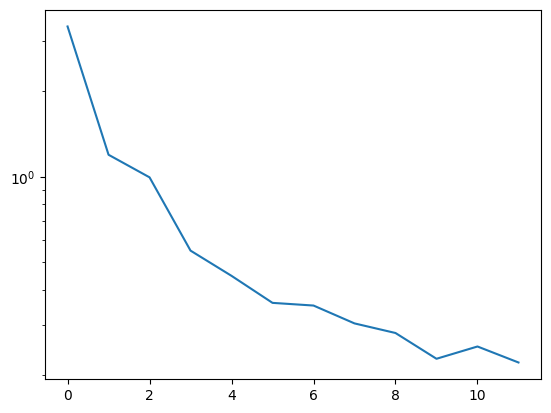

  6%|▌         | 2758/50000 [12:39<3:36:48,  3.63it/s, loss=1.97e-01]


KeyboardInterrupt: 

In [9]:
loss_history = train_drifting_with_vae(
    transformer,
    opt,
    T_list=[0.02, 0.05, 0.2],
    batch_size=48,
    gradient_accumulation=2,
    training_steps=50000,
    plot_every=250,
    seed=None,
    loss_scaling=1.0,
    save_step=2500,
    save_path="checkpoints/CelebA_18072026_pixel",
)

In [ ]:
# transformer.load_state_dict(
#     torch.load(
#         "/home/msst/repo/drifting/checkpoints/CelebA_14072026_ps2/transformer_step10000.pth"
#         )
#     )

In [ ]:
i = 0

12


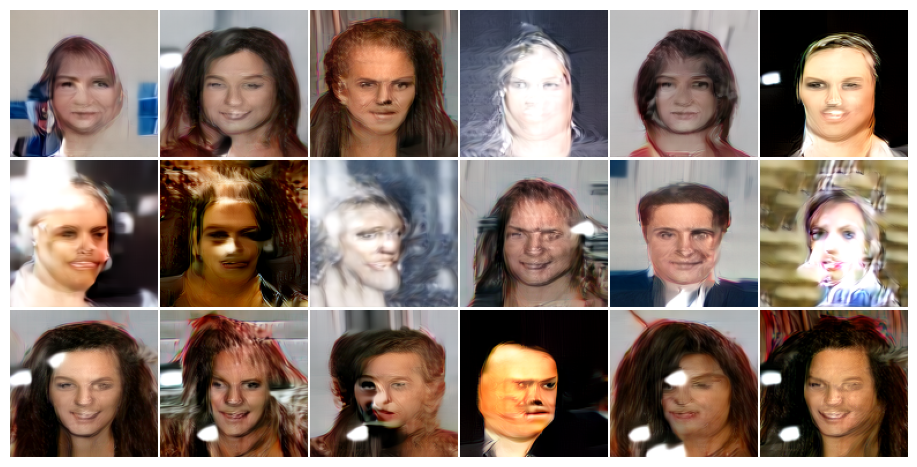

In [ ]:
batch_size = 18
i+= 1
print(i)
initial_seed = i

with torch.no_grad():
    noise = prepare_noise(
        batch_size, 
        (3, IMG_SIZE, IMG_SIZE), 
        device=DEVICE, 
        dtype=torch.bfloat16, 
        initial_seed=initial_seed
    )

    gen = transformer(noise)

    show_batch_grid(gen, n=6, figsize=(9, 9), denormalize=True)


In [ ]:
# # noise_A = torch.stack([noise[5], noise[31]])

# noise_grad = []
# N = 6
# for alpha in range(N):
#     n = noise[5] * alpha / (N - 1) + noise[31] * (1 - alpha / (N - 1))
#     noise_grad.append(n)
# noise_grad = torch.stack(noise_grad)


# with torch.no_grad():
#     gen_latent = transformer(noise_grad)
#     gen = vae.decode(gen_latent).sample
#     clear_output(wait=True)
#     show_batch_grid(gen, n=6, figsize=(8, 8), denormalize=True)